## Data Preparation & Train-Test Split

Load your clean data, isolate one predictor feature (MedInc), scale it so gradient descent converges smoothly, and split the data into training (80%) and testing (20%) sets.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
df = pd.read_csv('../data/raw/california_housing.csv')

# 2. Select 1 feature (X) and target variable (y)
X = df[['MedInc']].values
y = df['MedHouseVal'].values

# 3. Train/Test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature scaling (Standardize feature to mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 16512 samples
Testing set size: 4128 samples


## Linear Regression from Scratch (Gradient Descent)

Build a custom Python class that implements the gradient descent update loop from scratch.

In [2]:
class CustomLinearRegression:
    def __init__(self, lr=0.01, iterations=1000):
        self.lr = lr
        self.iterations = iterations
        self.theta_0 = 0.0  # Intercept
        self.theta_1 = 0.0  # Slope
        self.cost_history = []

    def fit(self, X, y):
        m = len(y)
        X_flat = X.flatten()

        for _ in range(self.iterations):
            # Predictions: h_theta(x) = theta_0 + theta_1 * x
            predictions = self.theta_0 + self.theta_1 * X_flat
            
            # Error = prediction - actual
            errors = predictions - y
            
            # Calculate Mean Squared Error (Cost)
            cost = (1 / (2 * m)) * np.sum(errors ** 2)
            self.cost_history.append(cost)
            
            # Gradient calculations
            d_theta_0 = (1 / m) * np.sum(errors)
            d_theta_1 = (1 / m) * np.sum(errors * X_flat)
            
            # Parameter updates
            self.theta_0 -= self.lr * d_theta_0
            self.theta_1 -= self.lr * d_theta_1

    def predict(self, X):
        return self.theta_0 + self.theta_1 * X.flatten()

# Train custom model
scratch_model = CustomLinearRegression(lr=0.05, iterations=1000)
scratch_model.fit(X_train_scaled, y_train)

print(f"Scratch Model -> Intercept (theta_0): {scratch_model.theta_0:.4f}, Slope (theta_1): {scratch_model.theta_1:.4f}")

Scratch Model -> Intercept (theta_0): 2.0719, Slope (theta_1): 0.7985


## Linear Regression using Scikit-Learn

Run Scikit-Learn's built-in LinearRegression model on the exact same data to verify if your custom math implementation produced the correct parameters.

In [3]:
from sklearn.linear_model import LinearRegression

# Train Scikit-Learn model
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_scaled, y_train)

print(f"Sklearn Model -> Intercept: {sklearn_model.intercept_:.4f}, Slope: {sklearn_model.coef_[0]:.4f}")

Sklearn Model -> Intercept: 2.0719, Slope: 0.7985


## Model Evaluation & Visualization

Evaluate predictions on the unseen test set using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and $R^2$ Score.

Evaluation Metrics (Test Set):
 - MAE:  0.6299
 - RMSE: 0.8421
 - R²:   0.4589


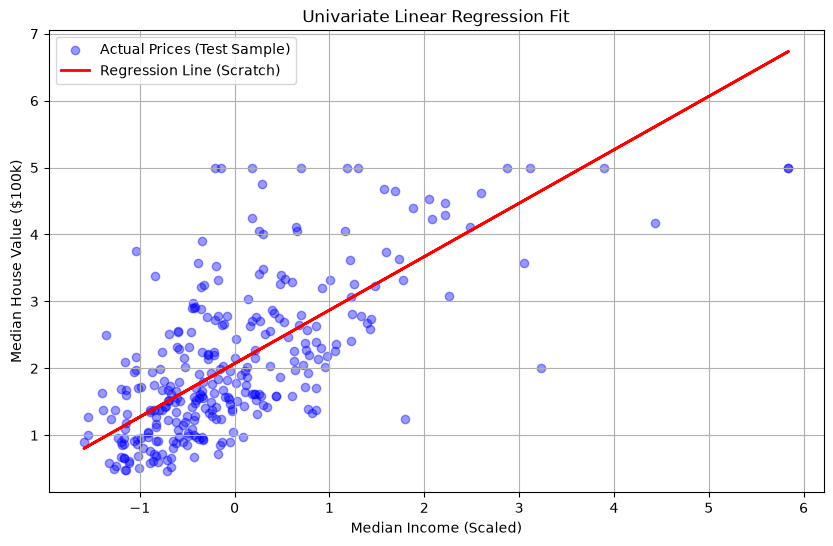

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generate predictions on test data
y_pred_scratch = scratch_model.predict(X_test_scaled)
y_pred_sklearn = sklearn_model.predict(X_test_scaled)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred_scratch)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_scratch))
r2 = r2_score(y_test, y_pred_scratch)

print(f"Evaluation Metrics (Test Set):\n - MAE:  {mae:.4f}\n - RMSE: {rmse:.4f}\n - R²:   {r2:.4f}")

# Plotting test data vs fitted regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test_scaled[:300], y_test[:300], alpha=0.4, color='blue', label='Actual Prices (Test Sample)')
plt.plot(X_test_scaled[:300], y_pred_scratch[:300], color='red', linewidth=2, label='Regression Line (Scratch)')
plt.xlabel('Median Income (Scaled)')
plt.ylabel('Median House Value ($100k)')
plt.title('Univariate Linear Regression Fit')
plt.legend()
plt.grid(True)
plt.show()